# 02 — GAN synthesis

Trains the TensorFlow GAN on the 450 real samples and produces 5,000 synthetic samples for the model notebooks.

Two GANs are trained, one per layout:

- **fixed GAN** sees the 450 real samples in the correct per-sample layout. Synthetic output feeds stages 2-4 of the four-stage narrative.
- **original GAN** sees the 450 real samples in the buggy C-order layout that the thesis used. Synthetic output feeds stage 1 (reproduce).

Same architecture, same seed, same epoch count. Different input distribution. This is what makes the synthetic-track reproduction honest.

Outputs:

- `data/synthetic/synth_fixed.npy` (5000, 25) for notebooks 3 and 4
- `data/synthetic/synth_original.npy` (5000, 25) for the reproduce track
- `data/synthetic/fixed/Data_Matrix_*.txt` and `data/synthetic/original/Data_Matrix_*.txt` for the MATLAB baseline
- `reports/figures/gan_losses.png` and `reports/figures/gan_distribution_check.png`


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from solder_reliability import find_repo_root
from solder_reliability.data_prep import load_raw
from solder_reliability import gan, viz

os.chdir(find_repo_root(Path.cwd()))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Load real data in both layouts

The GAN sees the full (450, 25) array, features plus target. The layout determines the pairing inside each row. The target column is identical between layouts.

In [2]:
RAW_DIR = Path('data/raw')
SYNTH_DIR = Path('data/synthetic')

X_fixed, y_fixed = load_raw(RAW_DIR, layout='fixed')
X_orig,  y_orig  = load_raw(RAW_DIR, layout='original')

data_fixed = np.hstack([X_fixed, y_fixed.reshape(-1, 1)])
data_orig  = np.hstack([X_orig,  y_orig.reshape(-1, 1)])

print('data_fixed   ', data_fixed.shape, data_fixed.dtype)
print('data_orig    ', data_orig.shape,  data_orig.dtype)
print()
print('same target column: ', bool(np.array_equal(data_fixed[:, -1], data_orig[:, -1])))
print('same feature block: ', bool(np.allclose(data_fixed[:, :24], data_orig[:, :24])))

data_fixed    (450, 25) float64
data_orig     (450, 25) float64

same target column:  True
same feature block:  False


## 2. Train the fixed-layout GAN

100 epochs, batch size 32, latent dim 100, seeds 42. Matches the thesis architecture and training schedule. Runs in well under a minute on CPU.

In [3]:
t0 = time.time()
gen_fixed, scaler_fixed, hist_fixed = gan.train_gan(
    data_fixed, epochs=100, verbose=True,
)
t_fixed = time.time() - t0
print(f'\nfixed GAN: 100 epochs in {t_fixed:.1f}s')

epoch  10/100  gen_loss=0.6842  disc_loss=1.0830
epoch  20/100  gen_loss=0.7687  disc_loss=1.4507


epoch  30/100  gen_loss=1.0496  disc_loss=1.1763
epoch  40/100  gen_loss=1.0835  disc_loss=1.1490


epoch  50/100  gen_loss=0.9489  disc_loss=1.1281
epoch  60/100  gen_loss=0.7238  disc_loss=1.2421


epoch  70/100  gen_loss=0.7758  disc_loss=1.2091
epoch  80/100  gen_loss=0.7627  disc_loss=1.2265


epoch  90/100  gen_loss=0.7427  disc_loss=1.2628
epoch 100/100  gen_loss=0.7446  disc_loss=1.2829

fixed GAN: 100 epochs in 2.5s


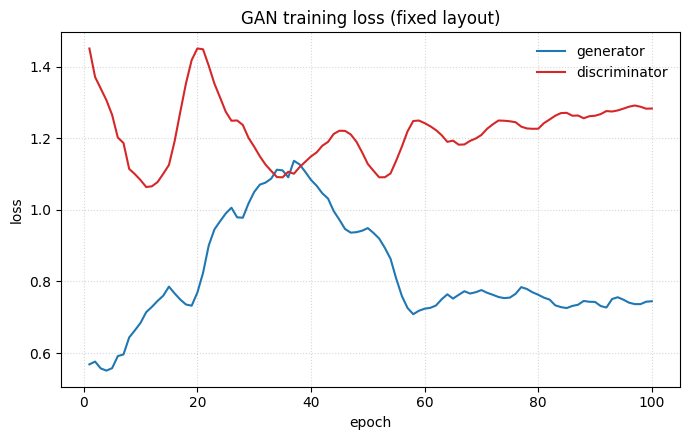

saved reports\figures\gan_losses.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
viz.plot_gan_losses(hist_fixed, title='GAN training loss (fixed layout)', ax=ax)
fig.tight_layout()
p = viz.save_figure(fig, 'gan_losses')
plt.show()
print('saved', p)

## 3. Generate 5,000 synthetic samples from the fixed GAN

The generator is called once after training with `num_samples=5000`. Output is in the original feature space, shape (5000, 25).

In [5]:
t0 = time.time()
synth_fixed = gan.generate_samples(gen_fixed, scaler_fixed, num_samples=5000)
t_gen = time.time() - t0
print(f'generated {synth_fixed.shape} in {t_gen:.1f}s')
print('finite:', bool(np.isfinite(synth_fixed).all()))
print()
print('real    per-column min  (first 5):', np.round(data_fixed.min(axis=0)[:5], 3))
print('synth   per-column min  (first 5):', np.round(synth_fixed.min(axis=0)[:5], 3))
print('real    per-column max  (first 5):', np.round(data_fixed.max(axis=0)[:5], 3))
print('synth   per-column max  (first 5):', np.round(synth_fixed.max(axis=0)[:5], 3))

generated (5000, 25) in 0.0s
finite: True

real    per-column min  (first 5): [90.    7.38  2.3   7.76  7.  ]
synth   per-column min  (first 5): [56.546  6.506  1.376  6.71   1.509]
real    per-column max  (first 5): [165.     8.4    2.3    7.76  18.  ]
synth   per-column max  (first 5): [251.466   9.293   3.439   8.765  33.078]


## 4. Real vs synthetic, marginal comparison

The GAN does not replicate the real joint distribution exactly. What we want to see: synthetic means are close to real means, synthetic stds are in the same ballpark. If a column has wildly different std, the GAN failed to learn that dimension.

Per-column mean and std, fixed layout, first 8 columns shown.

In [6]:
real_mean = data_fixed.mean(axis=0)
real_std  = data_fixed.std(axis=0)
syn_mean  = synth_fixed.mean(axis=0)
syn_std   = synth_fixed.std(axis=0)

print(f'{"col":>3}  {"real mean":>12s}  {"synth mean":>12s}  {"real std":>12s}  {"synth std":>12s}')
for i in range(min(8, data_fixed.shape[1])):
    print(f'{i:>3}  {real_mean[i]:>12.3f}  {syn_mean[i]:>12.3f}  {real_std[i]:>12.3f}  {syn_std[i]:>12.3f}')

print()
print('largest |real_mean - synth_mean|:',
      float(np.abs(real_mean - syn_mean).max()))
print('largest std ratio (synth / real):',
      float((syn_std / np.where(real_std > 0, real_std, 1)).max()))

col     real mean    synth mean      real std     synth std
  0       130.478       132.969        12.209        24.255
  1         7.720         7.747         0.481         0.349
  2         2.300         2.313         0.000         0.269
  3         7.760         7.723         0.000         0.248
  4        13.133        13.244         1.989         3.769
  5        22.100        22.013         1.951         1.473
  6         3.000         3.006         0.000         0.261
  7        24.800        24.843         0.000         0.280

largest |real_mean - synth_mean|: 273.1326996527787
largest std ratio (synth / real): 2519085560627200.0


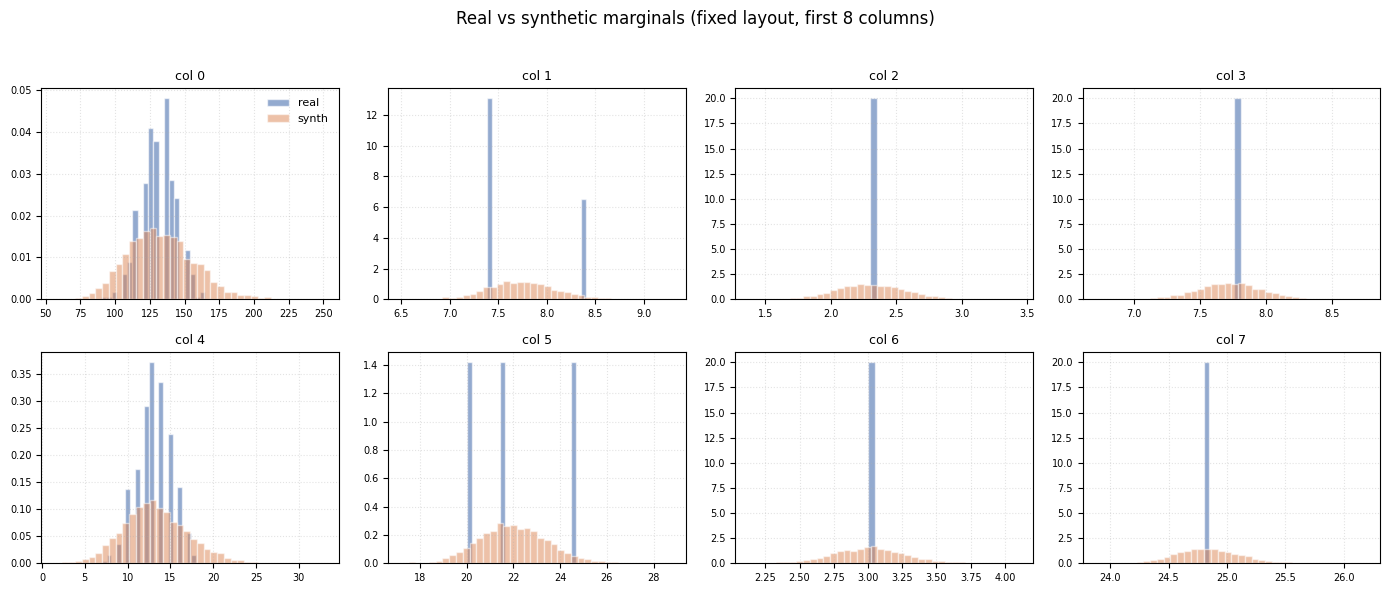

saved reports\figures\gan_distribution_check.png


In [7]:
# Plot a few columns: real histogram overlaid with synth histogram.
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i in range(8):
    ax = axes[i]
    ax.hist(data_fixed[:, i], bins=20, density=True, alpha=0.6,
            color='#4c72b0', edgecolor='white', label='real')
    ax.hist(synth_fixed[:, i], bins=40, density=True, alpha=0.5,
            color='#dd8452', edgecolor='white', label='synth')
    ax.set_title(f'col {i}', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(linestyle=':', alpha=0.35)
    if i == 0:
        ax.legend(frameon=False, fontsize=8)
fig.suptitle('Real vs synthetic marginals (fixed layout, first 8 columns)')
fig.tight_layout(rect=(0, 0, 1, 0.96))
p = viz.save_figure(fig, 'gan_distribution_check')
plt.show()
print('saved', p)

## 5. Train the original-layout GAN

Same architecture, same seed, trained on the buggy C-order layout. This is what the thesis actually did. Its synthetic output feeds the reproduce track in notebooks 3 and 4.

In [8]:
t0 = time.time()
gen_orig, scaler_orig, hist_orig = gan.train_gan(
    data_orig, epochs=100, verbose=False,
)
t_orig = time.time() - t0
print(f'original GAN: 100 epochs in {t_orig:.1f}s')
print('final gen_loss', round(hist_orig['gen_loss'][-1], 4),
      '| final disc_loss', round(hist_orig['disc_loss'][-1], 4))

original GAN: 100 epochs in 2.2s
final gen_loss 0.8651 | final disc_loss 1.0957


In [9]:
synth_orig = gan.generate_samples(gen_orig, scaler_orig, num_samples=5000)
print('synth_orig   ', synth_orig.shape, synth_orig.dtype)
print('finite:      ', bool(np.isfinite(synth_orig).all()))

synth_orig    (5000, 25) float32
finite:       True


## 6. Save the in-memory arrays

Notebooks 3 and 4 load these directly, no GAN retraining required. Shape (5000, 25), features in columns 0..23, target in column 24.

In [10]:
SYNTH_DIR.mkdir(parents=True, exist_ok=True)
np.save(SYNTH_DIR / 'synth_fixed.npy',    synth_fixed)
np.save(SYNTH_DIR / 'synth_original.npy', synth_orig)
print('wrote', SYNTH_DIR / 'synth_fixed.npy')
print('wrote', SYNTH_DIR / 'synth_original.npy')

wrote data\synthetic\synth_fixed.npy
wrote data\synthetic\synth_original.npy


## 7. Export .txt files for the MATLAB baseline

5,000 files per layout, 10,000 total. Each file is the 7x4 matrix format the MATLAB baseline reads.

This step is slow (about a minute). It can be commented out for quick reruns; the `.npy` files above are all the model notebooks need.

In [11]:
t0 = time.time()
n_fixed = gan.export_synthetic_txt(
    synth_fixed, SYNTH_DIR / 'fixed', layout='fixed',
)
n_orig = gan.export_synthetic_txt(
    synth_orig, SYNTH_DIR / 'original', layout='original',
)
t_exp = time.time() - t0
print(f'wrote {n_fixed} files to {SYNTH_DIR / "fixed"}')
print(f'wrote {n_orig} files to {SYNTH_DIR / "original"}')
print(f'export took {t_exp:.1f}s')

wrote 5000 files to data\synthetic\fixed
wrote 5000 files to data\synthetic\original
export took 10.0s


## 8. Reproduction caveat

GAN training is stochastic. Same seed, same library versions, same hardware gives the same result. Across TensorFlow versions, CPUs versus GPUs, or different BLAS backends, the exact 5,000 synthetic values will drift.

This is documented in `data/README.md`. It is the reason the synthetic dataset is published as a Release asset rather than regenerated from source alone. What this notebook produces is a statistically similar dataset, not the byte-identical one used for the published tables.

The deltas between the four stages are what this project reports. Absolute synthetic values are reproducible to within that caveat.


## 9. Takeaways

- Two GANs trained, one per layout. The fixed GAN feeds stages 2-4, the original GAN feeds stage 1 (reproduce).
- `synth_fixed.npy` and `synth_original.npy` are the handoff to notebooks 3 and 4. No GAN retraining downstream.
- The MATLAB baseline gets `.txt` files in both layouts, so it can be run against whichever synthetic dataset the write-up compares.
- The real-vs-synthetic marginal check is a sanity gate. If a future run shows a wildly different std for a column, the GAN failed on that dimension and the model results downstream would be suspect.

Next: `03_model_training_real.ipynb`, which runs the four-stage narrative on the 450 real samples.
